In [ ]:
# Problem Definition

objective = "Classification: Survived (Yes/No)"
success_criteria = "Accuracy > 80%"
constraints = "Limited features, missing values, imbalanced classes"

print("Objective:", objective)
print("Success Criteria:", success_criteria)
print("Constraints:", constraints)

Objective: Classification: Survived (Yes/No)
Success Criteria: Accuracy > 80%
Constraints: Limited features, missing values, imbalanced classes


In [ ]:
import pandas as pd
import seaborn as sns

# Load Titanic dataset
df = sns.load_dataset("titanic")

print("Data Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

Data Shape: (891, 15)

First 5 Rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [ ]:
import pandas as pd
import seaborn as sns

# Load dataset
df = sns.load_dataset("titanic")

# Fill missing values
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Drop duplicate rows
df.drop_duplicates(inplace=True)

# Feature Engineering
df['family_size'] = df['sibsp'] + df['parch']

# Convert categorical columns into numeric
df = pd.get_dummies(
    df,
    columns=['sex', 'class', 'embarked'],
    drop_first=True
)

print(df.head())

   survived  pclass   age  sibsp  parch     fare    who  adult_male deck  \
0         0       3  22.0      1      0   7.2500    man        True  NaN   
1         1       1  38.0      1      0  71.2833  woman       False    C   
2         1       3  26.0      0      0   7.9250  woman       False  NaN   
3         1       1  35.0      1      0  53.1000  woman       False    C   
4         0       3  35.0      0      0   8.0500    man        True  NaN   

   embark_town alive  alone  family_size  sex_male  class_Second  class_Third  \
0  Southampton    no  False            1      True         False         True   
1    Cherbourg   yes  False            1     False         False        False   
2  Southampton   yes   True            0     False         False         True   
3  Southampton   yes  False            1     False         False        False   
4  Southampton    no   True            0      True         False         True   

   embarked_Q  embarked_S  
0       False        True  


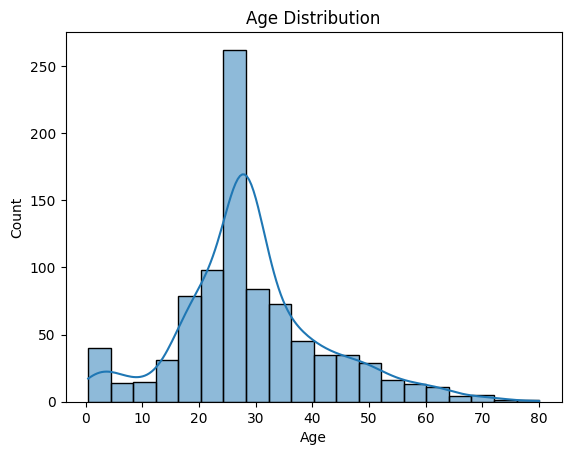

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = sns.load_dataset("titanic")

# Fill missing age values
df['age'] = df['age'].fillna(df['age'].median())

sns.histplot(df['age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

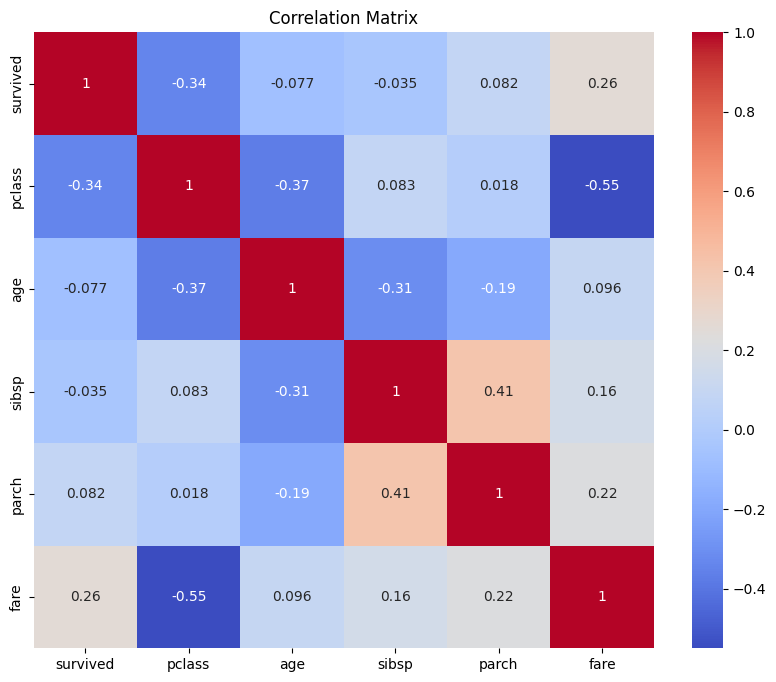

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = sns.load_dataset("titanic")

# Keep only numeric columns
numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load dataset
df = sns.load_dataset("titanic")

# Handle missing values
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Remove rows with missing target values
df = df.dropna(subset=['survived'])

# Convert categorical variables
df = pd.get_dummies(df, drop_first=True)

# Replace any remaining missing values
df = df.fillna(0)

# Features and Target
X = df.drop('survived', axis=1)
y = df['survived']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Logistic Regression Model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

# Predict
y_pred = model.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred))

print("Recall:",
      recall_score(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Confusion Matrix:
[[105   0]
 [  0  74]]
